# KL-VAE & VQ-VAE Inference Notebook

Load trained models and perform inference/generation tasks:
- Load saved models from disk
- Generate random samples
- Interpolate between images
- Reconstruct test images
- Visualize results

## 1. Environment Setup

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
import zipfile
import urllib.request
import warnings

warnings.filterwarnings('ignore')

print('=== Inference Setup ===')
cuda_available = torch.cuda.is_available()
print(f'CUDA Available: {cuda_available}')

if cuda_available:
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print(f'Device: {device}')

=== Inference Setup ===
CUDA Available: True
GPU: NVIDIA GeForce RTX 5070 Ti
Device: cuda


## 2. Model Definitions (Same as training)

In [2]:
class KL_VAE(nn.Module):
    def __init__(self, latent_dim=32):
        super(KL_VAE, self).__init__()
        self.latent_dim = latent_dim
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(128, 256, 4, 2, 1), nn.ReLU(),
        )
        self.fc_mu = nn.Linear(256*4*4, latent_dim)
        self.fc_logvar = nn.Linear(256*4*4, latent_dim)
        self.fc_decode = nn.Linear(latent_dim, 256*4*4)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, 2, 1), nn.Tanh()
        )
    def encode(self, x):
        h = self.encoder(x).view(x.size(0), -1)
        return self.fc_mu(h), self.fc_logvar(h)
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)
        return mu + eps*std
    def decode(self, z):
        h = self.fc_decode(z).view(z.size(0), 256, 4, 4)
        return self.decoder(h)
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar
    def sample(self, num_samples=16):
        with torch.no_grad():
            z = torch.randn(num_samples, self.latent_dim, device=next(self.parameters()).device)
            return self.decode(z)

print('KL-VAE defined')

KL-VAE defined


In [3]:
class VectorQuantizer(nn.Module):
    def __init__(self, num_codes=512, code_dim=64, beta=0.99):
        super().__init__()
        self.num_codes = num_codes
        self.code_dim = code_dim
        self.beta = beta
        self.codebook = nn.Embedding(num_codes, code_dim)
        self.codebook.weight.data.uniform_(-1.0/num_codes, 1.0/num_codes)
    
    def forward(self, x):
        original_shape = x.shape
        if len(x.shape) == 4:
            x_permuted = x.permute(0, 2, 3, 1).contiguous()
            x_flat = x_permuted.view(-1, self.code_dim)
        else:
            x_flat = x.view(-1, self.code_dim)
        
        distances = torch.cdist(x_flat, self.codebook.weight)
        indices = torch.argmin(distances, dim=1)
        quantized_flat = self.codebook(indices)
        
        commitment_loss = torch.mean((quantized_flat.detach() - x_flat)**2)
        codebook_loss = torch.mean((quantized_flat - x_flat.detach())**2)
        loss = commitment_loss + self.beta * codebook_loss
        
        quantized_flat = x_flat + (quantized_flat - x_flat).detach()
        
        if len(original_shape) == 4:
            quantized = quantized_flat.view(original_shape[0], original_shape[2], original_shape[3], self.code_dim)
            quantized = quantized.permute(0, 3, 1, 2).contiguous()
        else:
            quantized = quantized_flat.view(original_shape)
        
        return {'quantized': quantized, 'loss': loss, 'indices': indices}

print('VectorQuantizer defined')

VectorQuantizer defined


In [4]:
class VQ_VAE(nn.Module):
    def __init__(self, num_codes=512, code_dim=64):
        super().__init__()
        self.num_codes = num_codes
        self.code_dim = code_dim
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(128, code_dim, 4, 2, 1),
        )
        self.quantizer = VectorQuantizer(num_codes, code_dim)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(code_dim, 128, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, 2, 1), nn.Tanh()
        )
    def encode(self, x):
        return self.quantizer(self.encoder(x))
    def decode(self, quantized):
        return self.decoder(quantized)
    def forward(self, x):
        qr = self.encode(x)
        return {'reconstruction': self.decode(qr['quantized']), 'loss': qr['loss'], 'indices': qr['indices']}
    def sample_random(self, num_samples=16):
        with torch.no_grad():
            device = next(self.parameters()).device
            idx = torch.randint(0, self.num_codes, (num_samples, 4, 4), device=device)
            q = self.quantizer.codebook(idx.view(-1)).view(num_samples, 4, 4, self.code_dim)
            q = q.permute(0,3,1,2).contiguous()
            return self.decode(q)

print('VQ-VAE defined')

VQ-VAE defined


## 3. Load Trained Models

In [5]:
model_dir = Path('models')

# Load KL-VAE
kl_vae = KL_VAE(latent_dim=32).to(device)
kl_vae.load_state_dict(torch.load(model_dir / 'kl_vae.pth', map_location=device))
kl_vae.eval()
print('KL-VAE loaded successfully')

# Load VQ-VAE
vq_vae = VQ_VAE(num_codes=512, code_dim=64).to(device)
vq_vae.load_state_dict(torch.load(model_dir / 'vq_vae.pth', map_location=device))
vq_vae.eval()
print('VQ-VAE loaded successfully')

print(f'\nModels loaded on device: {device}')

KL-VAE loaded successfully
VQ-VAE loaded successfully

Models loaded on device: cuda


## 4. Helper Functions

In [6]:
def denorm(img):
    """Denormalize image from [-1, 1] to [0, 1]"""
    return (img + 1) / 2

def load_image(image_path, device, img_size=64):
    """Load and preprocess single image"""
    transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
    image = Image.open(image_path).convert('RGB')
    return transform(image).unsqueeze(0).to(device)

def calc_metrics(orig, recon):
    """Calculate MSE and PSNR"""
    mse = torch.mean((orig - recon)**2).item()
    if mse < 1e-10:
        psnr = 100
    else:
        psnr = 20 * np.log10(2 / np.sqrt(mse))
    return mse, psnr

print('Helper functions defined')

Helper functions defined


## 5. Generation: Random Samples

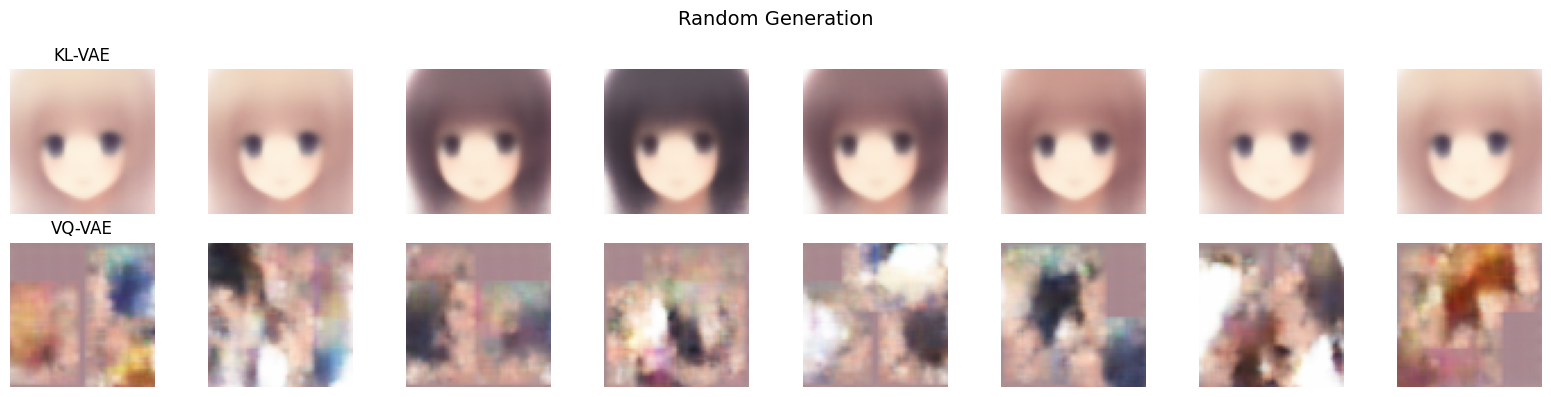

Generated 8 random samples from each model


In [7]:
# Generate random samples from both models
num_samples = 8

with torch.no_grad():
    kl_samples = kl_vae.sample(num_samples)
    vq_samples = vq_vae.sample_random(num_samples)

# Visualize
fig, axes = plt.subplots(2, num_samples, figsize=(16, 4))

for i in range(num_samples):
    img_kl = denorm(kl_samples[i].cpu()).permute(1, 2, 0)
    axes[0, i].imshow(np.clip(img_kl.numpy(), 0, 1))
    axes[0, i].set_title('KL-VAE' if i == 0 else '')
    axes[0, i].axis('off')
    
    img_vq = denorm(vq_samples[i].cpu()).permute(1, 2, 0)
    axes[1, i].imshow(np.clip(img_vq.numpy(), 0, 1))
    axes[1, i].set_title('VQ-VAE' if i == 0 else '')
    axes[1, i].axis('off')

plt.suptitle('Random Generation', fontsize=14)
plt.tight_layout()
plt.show()

print(f'Generated {num_samples} random samples from each model')

## 6. Generation: Latent Space Interpolation

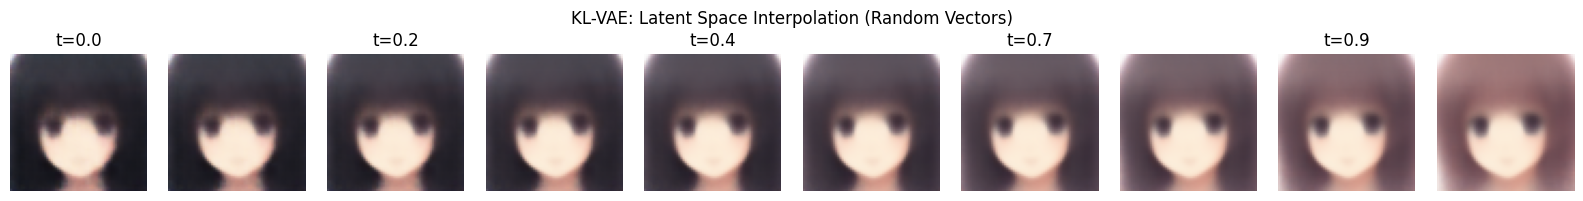

Interpolated between two random latent vectors in 10 steps


In [19]:
def kl_interpolate_latent(model, z1, z2, steps=10):
    """Interpolate between two latent vectors in KL-VAE"""
    model.eval()
    with torch.no_grad():
        interpolated = []
        for t in np.linspace(0, 1, steps):
            z_t = (1 - t) * z1 + t * z2
            recon = model.decode(z_t)
            interpolated.append(denorm(recon[0].cpu()).permute(1, 2, 0))
    return interpolated

# Generate two random latent vectors and interpolate
steps = 10
z1 = torch.randn(1, 32, device=device)
z2 = torch.randn(1, 32, device=device)
interp_images = kl_interpolate_latent(kl_vae, z1, z2, steps=steps)

# Visualize
fig, axes = plt.subplots(1, steps, figsize=(16, 2))
for i, img in enumerate(interp_images):
    axes[i].imshow(np.clip(img.numpy(), 0, 1))
    axes[i].set_title(f't={i/(steps-1):.1f}' if i % 2 == 0 else '')
    axes[i].axis('off')

plt.suptitle('KL-VAE: Latent Space Interpolation (Random Vectors)', fontsize=12)
plt.tight_layout()
plt.show()

print(f'Interpolated between two random latent vectors in {steps} steps')

## 7. Reconstruction: Test Images from Dataset

In [9]:
# Load a few test images from dataset
class AnimeDataset(Dataset):
    def __init__(self, image_dir, img_size=64, transform=None):
        self.image_dir = Path(image_dir)
        self.img_size = img_size
        self.transform = transform
        
        self.image_files = list(self.image_dir.glob('*.png')) + list(self.image_dir.glob('*.jpg'))
        if len(self.image_files) == 0:
            for subdir in self.image_dir.iterdir():
                if subdir.is_dir():
                    self.image_files.extend(list(subdir.glob('*.png')))
                    self.image_files.extend(list(subdir.glob('*.jpg')))
        
        self.image_files = sorted(self.image_files)
        
    def __len__(self):
        return len(self.image_files)
    
    def __getitem__(self, idx):
        img_path = self.image_files[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Load dataset
anime_dataset = AnimeDataset('dataset', img_size=64, transform=transform)
test_loader = DataLoader(anime_dataset, batch_size=32, shuffle=True, num_workers=0)

print(f'Dataset loaded: {len(anime_dataset)} images')

Dataset loaded: 63565 images


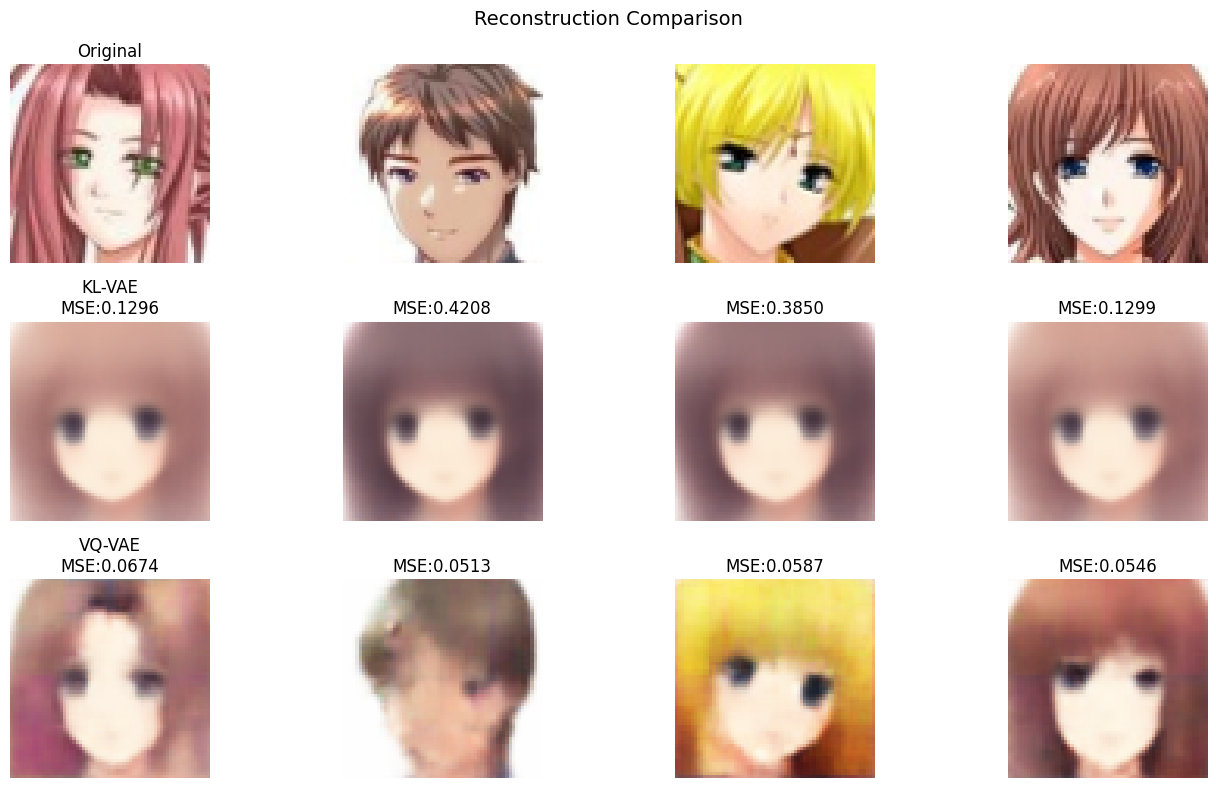

Reconstructed 4 images
KL-VAE avg MSE: 0.266328
VQ-VAE avg MSE: 0.058013


In [10]:
# Load one batch and reconstruct
with torch.no_grad():
    test_batch = next(iter(test_loader)).to(device)
    
    # KL-VAE reconstruction
    kl_recon, _, _ = kl_vae(test_batch)
    
    # VQ-VAE reconstruction
    vq_out = vq_vae(test_batch)
    vq_recon = vq_out['reconstruction']

# Calculate metrics for first few images
num_display = 4
kl_mse_vals = []
vq_mse_vals = []

for i in range(min(num_display, test_batch.size(0))):
    kl_m, _ = calc_metrics(test_batch[i:i+1], kl_recon[i:i+1])
    vq_m, _ = calc_metrics(test_batch[i:i+1], vq_recon[i:i+1])
    kl_mse_vals.append(kl_m)
    vq_mse_vals.append(vq_m)

# Visualize
fig, axes = plt.subplots(3, num_display, figsize=(14, 8))

for i in range(num_display):
    # Original
    img_orig = denorm(test_batch[i].cpu()).permute(1, 2, 0)
    axes[0, i].imshow(np.clip(img_orig.numpy(), 0, 1))
    axes[0, i].set_title('Original' if i == 0 else '')
    axes[0, i].axis('off')
    
    # KL-VAE
    img_kl = denorm(kl_recon[i].cpu()).permute(1, 2, 0)
    axes[1, i].imshow(np.clip(img_kl.numpy(), 0, 1))
    axes[1, i].set_title(f'KL-VAE\nMSE:{kl_mse_vals[i]:.4f}' if i == 0 else f'MSE:{kl_mse_vals[i]:.4f}')
    axes[1, i].axis('off')
    
    # VQ-VAE
    img_vq = denorm(vq_recon[i].cpu()).permute(1, 2, 0)
    axes[2, i].imshow(np.clip(img_vq.numpy(), 0, 1))
    axes[2, i].set_title(f'VQ-VAE\nMSE:{vq_mse_vals[i]:.4f}' if i == 0 else f'MSE:{vq_mse_vals[i]:.4f}')
    axes[2, i].axis('off')

plt.suptitle('Reconstruction Comparison', fontsize=14)
plt.tight_layout()
plt.show()

print(f'Reconstructed {num_display} images')
print(f'KL-VAE avg MSE: {np.mean(kl_mse_vals):.6f}')
print(f'VQ-VAE avg MSE: {np.mean(vq_mse_vals):.6f}')

## 8. Advanced: Encode-Decode from Real Images

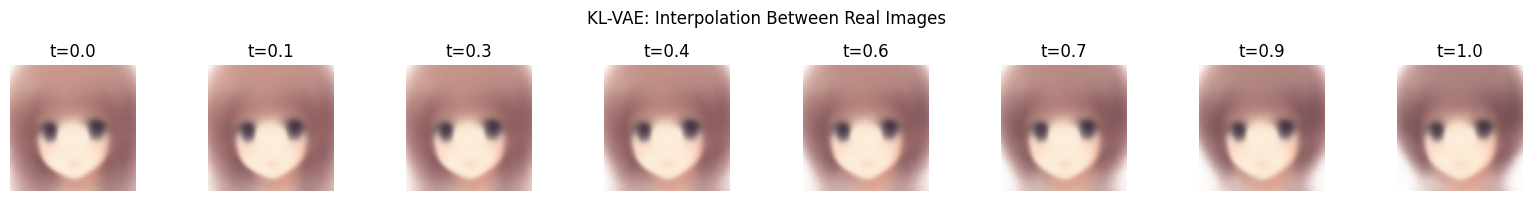

Interpolated between 2 real images in 8 steps


In [11]:
# Get 2 images and interpolate through their latent representations
with torch.no_grad():
    img1 = test_batch[0:1].to(device)
    img2 = test_batch[1:1+1].to(device)
    
    # KL-VAE: Get latent vectors
    mu1, _ = kl_vae.encode(img1)
    mu2, _ = kl_vae.encode(img2)
    
    # Interpolate in latent space
    steps = 8
    kl_interp_result = []
    for t in np.linspace(0, 1, steps):
        mu_t = (1 - t) * mu1 + t * mu2
        recon = kl_vae.decode(mu_t)
        kl_interp_result.append(denorm(recon[0].cpu()).permute(1, 2, 0))

# Visualize
fig, axes = plt.subplots(1, steps, figsize=(16, 2))
for i, img in enumerate(kl_interp_result):
    axes[i].imshow(np.clip(img.numpy(), 0, 1))
    axes[i].set_title(f't={i/(steps-1):.1f}')
    axes[i].axis('off')

plt.suptitle('KL-VAE: Interpolation Between Real Images', fontsize=12)
plt.tight_layout()
plt.show()

print(f'Interpolated between 2 real images in {steps} steps')

## 9. Batch Inference: Evaluation Metrics

In [12]:
# Evaluate on a larger batch
print('Computing metrics on test set...')

kl_mse_list = []
vq_mse_list = []
kl_psnr_list = []
vq_psnr_list = []

with torch.no_grad():
    for batch_idx, data in enumerate(test_loader):
        if batch_idx >= 5:  # Use first 5 batches for speed
            break
        
        data = data.to(device)
        
        # KL-VAE
        kl_r, _, _ = kl_vae(data)
        m, p = calc_metrics(data, kl_r)
        kl_mse_list.append(m)
        kl_psnr_list.append(p)
        
        # VQ-VAE
        vq_out = vq_vae(data)
        vq_r = vq_out['reconstruction']
        m, p = calc_metrics(data, vq_r)
        vq_mse_list.append(m)
        vq_psnr_list.append(p)

print('\n' + '='*60)
print('INFERENCE METRICS (5 batches)')
print('='*60)
print(f'KL-VAE:')
print(f'  MSE:  {np.mean(kl_mse_list):.6f} (+/- {np.std(kl_mse_list):.6f})')
print(f'  PSNR: {np.mean(kl_psnr_list):.4f} dB')
print(f'\nVQ-VAE:')
print(f'  MSE:  {np.mean(vq_mse_list):.6f} (+/- {np.std(vq_mse_list):.6f})')
print(f'  PSNR: {np.mean(vq_psnr_list):.4f} dB')
print('='*60)

Computing metrics on test set...

INFERENCE METRICS (5 batches)
KL-VAE:
  MSE:  0.206278 (+/- 0.014381)
  PSNR: 12.8867 dB

VQ-VAE:
  MSE:  0.080059 (+/- 0.005313)
  PSNR: 16.9960 dB
